<a href="https://colab.research.google.com/github/XuShuqi7/NCrystal-based_Neutron_Imaging_Fitting_Script/blob/main/Theoretical_trans_spec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preamble (adopted from ncrystal-notebook)

In [68]:
#By default we only do pip installs on Google Colab, but you
#can set the variable in the next line to True if you need it:
always_do_pip_installs = False
try:
    import google.colab as google_colab
except ModuleNotFoundError:
    google_colab=None#not on google colab
if always_do_pip_installs or google_colab:
    %pip -q install ncrystal[plot] ipympl
#enable inline and interactive matplotlib plots:
if google_colab:
    google_colab.output.enable_custom_widget_manager()
    %matplotlib inline
else:
    %matplotlib ipympl
import matplotlib
matplotlib.rcParams.update({"figure.autolayout": True})
#always import NCrystal:
import NCrystal as NC
assert NC.version_num >=  4000000, "too old NCrystal found"
NC.test() #< quick unit test that installation works

Tests completed succesfully


# Necessary packages

In [69]:
import numpy as np
import matplotlib.pyplot as plt

# Convert weight fraction to volumn fraction

In [70]:
def calc_compo(elem_list, wts, base_element='Fe'):
    """
    Calculate atomic composition, remove elements rounding to 0.000,
    and ensure the sum is exactly 1.000.
    """
    if len(elem_list) != len(wts):
        raise ValueError("Element list and weight list must have the same length.")

    total_wt = np.sum(wts)
    if total_wt > 100:
        raise ValueError("Total weight percentage exceeds 100%.")

    # 1. Compute missing base element weight
    base_wt = 100 - total_wt

    # 2. Merge base element into the weight lists
    # We use a dictionary to easily handle potential duplicates
    compo_dict = dict(zip(elem_list, wts))
    compo_dict[base_element] = compo_dict.get(base_element, 0) + base_wt

    # 3. Calculate atomic fractions
    # Map element -> raw atomic fraction
    elements = list(compo_dict.keys())

    # Assuming NC and atomdata are globally available as in your snippet
    atomic_fractions = np.array([
        compo_dict[e] / NC.atomDB(NC.atomdata.elementNameToZValue(e)).averageMassAMU()
        for e in elements
    ])

    # Normalize raw fractions to sum to 1.0
    atomic_fractions /= np.sum(atomic_fractions)

    # 4. Filter out elements that round to 0.000
    # Keep only elements where the fraction is >= 0.0005
    final_elements = []
    final_wts = []

    for e, w in zip(elements, atomic_fractions):
        rounded_val = np.round(w, 3)
        if rounded_val > 0:
            final_elements.append(e)
            final_wts.append(rounded_val)

    final_wts = np.array(final_wts)

    # 5. Fix rounding error
    # Apply the difference to the base_element to ensure sum is exactly 1.000
    rounding_error = 1.000 - np.sum(final_wts)

    if base_element in final_elements:
        base_idx = final_elements.index(base_element)
        final_wts[base_idx] = round(final_wts[base_idx] + rounding_error, 3)
    else:
        # If the base element was somehow filtered out (extremely trace),
        # apply to the element with the largest fraction instead.
        max_idx = np.argmax(final_wts)
        final_wts[max_idx] = round(final_wts[max_idx] + rounding_error, 3)

    # 6. Format the output string
    # We re-format to :.3f to ensure 0.1 is 0.100
    pairs = [f"{wt:.3f}:{elem}" for elem, wt in zip(final_elements, final_wts)]
    result = f"atomdb={base_element}:is:" + ":".join(pairs)

    print(result)

    return result

In [71]:
material = "IN738LC"
density = 8.2 # g/cm3
sample_thickness = 0.3 # cm

In [72]:
# Duplex weight fraction
elem_list = [ 'Ti', 'Al', 'Mn', 'Mo', 'Ta', 'C',  'Co',  'W',  'Nb', 'Fe',  'Cr',  'B'  ] # from Materials & Design 257 (2025) 114378
wts       = [ 3.45, 3.21, 0.01, 1.68, 1.75, 0.05, 8.49,  2.77, 0.84,  0.02, 16.72, 0.003]

In [73]:
# convert to volumn fraction to feed into atomdb
atomdb = calc_compo(elem_list, wts, base_element='Ni')

atomdb=Ni:is:0.041:Ti:0.068:Al:0.010:Mo:0.006:Ta:0.002:C:0.082:Co:0.009:W:0.005:Nb:0.183:Cr:0.594:Ni


In [74]:
wl = np.linspace(0,10,10000)
ekinE = NC.wl2ekin(wl)
cfg = "Ni_sg225.ncmat;density={}gcm3;{}".format(density,atomdb)
pc   = NC.createScatter(cfg)
pc_a = NC.createAbsorption(cfg)
info = NC.createInfo(cfg)
xsect = pc.crossSectionIsotropic(ekinE) + pc_a.crossSectionIsotropic(ekinE)

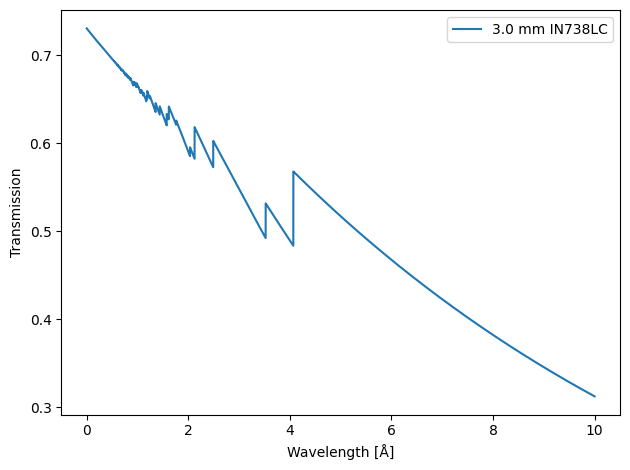

In [75]:
plt.figure()
plt.plot(wl,np.exp(-xsect*info.numberdensity*sample_thickness), label=f'{sample_thickness*10} mm {material}')
plt.xlabel('Wavelength [Å]')
plt.ylabel('Transmission')
a = plt.legend()